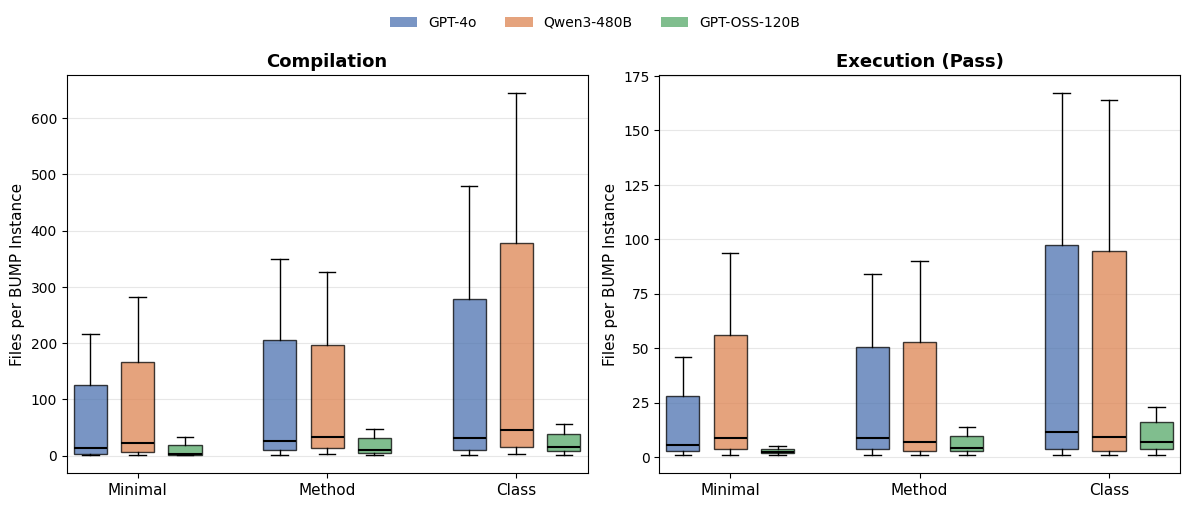

Saved: boxplot_per_instance_stats.pdf / .png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ---------------------------------------------------------------------
# DATA: Replace these with your actual per-instance distributions.
# Each entry is a list of file counts per BUMP instance.
# Below are synthetic samples that match the reported median & range.
# ---------------------------------------------------------------------

def synthetic(n_inst, median, lo, hi, size_approx=50):
    """Generate a rough synthetic distribution matching median/range."""
    rng = np.random.default_rng(42)
    left = rng.integers(lo, max(median, lo + 1), size=size_approx // 2)
    right = rng.integers(median, hi + 1, size=size_approx // 2)
    data = np.concatenate([left, right])
    return data

# --- Compilation data (median, min, max) per (context, model) ---
comp_stats = {
    ("Minimal", "GPT-4o"):       (7.0,   1, 222),
    ("Minimal", "Qwen3-480B"):   (14.0,  1, 291),
    ("Minimal", "GPT-OSS-120B"): (3.5,   1, 33),
    ("Method",  "GPT-4o"):       (17.0,  1, 359),
    ("Method",  "Qwen3-480B"):   (25.0,  1, 336),
    ("Method",  "GPT-OSS-120B"): (10.5,  1, 49),
    ("Class",   "GPT-4o"):       (17.0,  1, 492),
    ("Class",   "Qwen3-480B"):   (27.0,  1, 662),
    ("Class",   "GPT-OSS-120B"): (15.5,  1, 57),
}

exec_stats = {
    ("Minimal", "GPT-4o"):       (5.0, 1, 47),
    ("Minimal", "Qwen3-480B"):   (7.0, 1, 96),
    ("Minimal", "GPT-OSS-120B"): (3.0, 1, 5),
    ("Method",  "GPT-4o"):       (7.0, 1, 86),
    ("Method",  "Qwen3-480B"):   (5.5, 1, 92),
    ("Method",  "GPT-OSS-120B"): (5.0, 1, 14),
    ("Class",   "GPT-4o"):       (7.0, 1, 171),
    ("Class",   "Qwen3-480B"):   (5.5, 1, 168),
    ("Class",   "GPT-OSS-120B"): (7.0, 1, 23),
}

# Generate synthetic data (REPLACE with real data for final figure)
comp_data = {k: synthetic(50, *v) for k, v in comp_stats.items()}
exec_data = {k: synthetic(50, *v) for k, v in exec_stats.items()}

# ---------------------------------------------------------------------
# PLOT
# ---------------------------------------------------------------------
contexts = ["Minimal", "Method", "Class"]
models = ["GPT-4o", "Qwen3-480B", "GPT-OSS-120B"]
colors = {"GPT-4o": "#4C72B0", "Qwen3-480B": "#DD8452", "GPT-OSS-120B": "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, (data, title) in zip(axes, [(comp_data, "Compilation"), (exec_data, "Execution (Pass)")]):
    positions = []
    box_data = []
    tick_positions = []
    tick_labels = []
    box_colors = []

    for ci, ctx in enumerate(contexts):
        base = ci * 4  # spacing between context groups
        for mi, model in enumerate(models):
            pos = base + mi
            positions.append(pos)
            box_data.append(data[(ctx, model)])
            box_colors.append(colors[model])
        tick_positions.append(base + 1)
        tick_labels.append(ctx)

    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=0.7,
        patch_artist=True,
        showfliers=True,
        flierprops=dict(marker="o", markersize=3, alpha=0.5),
        medianprops=dict(color="black", linewidth=1.5),
    )

    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Files per BUMP Instance", fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

# Legend
handles = [mpatches.Patch(facecolor=colors[m], label=m, alpha=0.75) for m in models]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, 1.02), frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("boxplot_per_instance_stats.pdf", bbox_inches="tight", dpi=300)
plt.savefig("boxplot_per_instance_stats.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved: boxplot_per_instance_stats.pdf / .png")

I want to see, how much a project contributed out of 5790 total call sights among 89 projects we are analysing. Since we prompt LLM for each client methods in which it finds call sights, I will take the number of test files generated as a count per project contributing to the call sights.

In [2]:
!pip3 install squarify

Total usages found : 5790
Expected total     : 5790
✓ Match


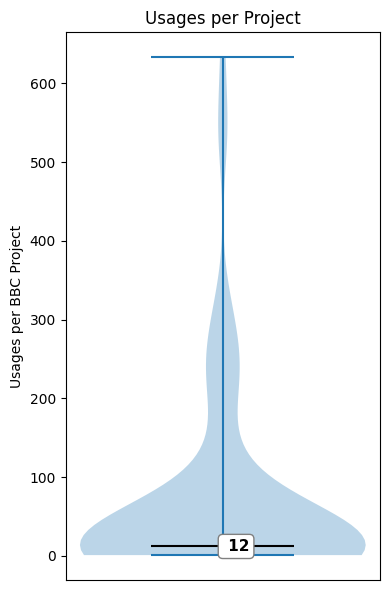

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- CONFIG ---
EXP7_PATH = "/Volumes/Rachna-HD/FilteredDataset/Exp7Prompts"  
TOTAL_EXPECTED = 5790

# --- COUNT USAGES PER PROJECT ---
rows = []
for project in sorted(os.listdir(EXP7_PATH)):
    project_dir = os.path.join(EXP7_PATH, project)
    if os.path.isdir(project_dir):
        usages = sum(1 for f in os.listdir(project_dir) if f.endswith(".txt"))
        rows.append({"project": project, "usages": usages})

df = pd.DataFrame(rows).sort_values("usages", ascending=False)

# --- VALIDATE ---
actual_total = df["usages"].sum()
print(f"Total usages found : {actual_total}")
print(f"Expected total     : {TOTAL_EXPECTED}")
print("✓ Match" if actual_total == TOTAL_EXPECTED else f"✗ Mismatch by {actual_total - TOTAL_EXPECTED:+d}")

# --- OPTION 1: VIOLIN PLOT (like your image) ---
fig, ax = plt.subplots(figsize=(4, 6))
parts = ax.violinplot(df["usages"], positions=[1], showmedians=True, showextrema=True)
parts["cmedians"].set_color("black")
median_val = int(df["usages"].median())
ax.text(1, median_val, f" {median_val}", ha="left", va="center",
        fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray"))
ax.set_xticks([])
ax.set_ylabel("Usages per BBC Project")
ax.set_title("Usages per Project")
plt.tight_layout()
plt.savefig("violin_usages.png", dpi=150)
plt.show()



Total usages found : 5790
Expected total     : 5790
✓ Match


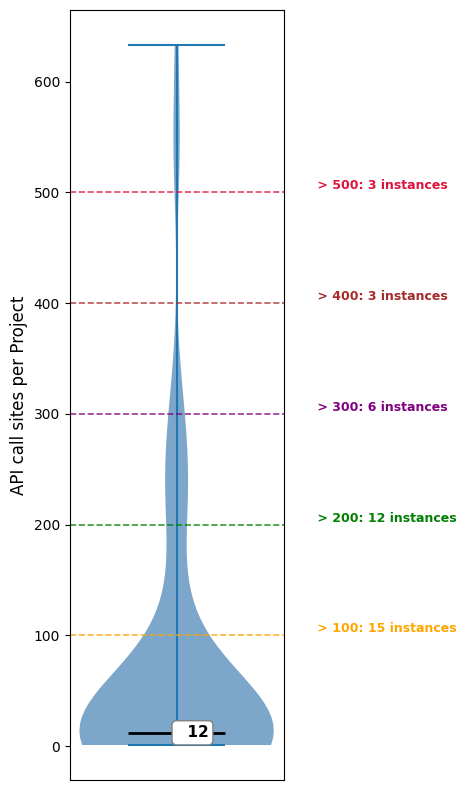

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIG ---
EXP7_PATH = "/Volumes/Rachna-HD/FilteredDataset/Exp7Prompts"  # <-- update this
TOTAL_EXPECTED = 5790

# --- COUNT USAGES PER PROJECT ---
rows = []
for project in sorted(os.listdir(EXP7_PATH)):
    project_dir = os.path.join(EXP7_PATH, project)
    if os.path.isdir(project_dir):
        usages = sum(1 for f in os.listdir(project_dir) if f.endswith(".txt"))
        rows.append({"project": project, "usages": usages})

df = pd.DataFrame(rows).sort_values("usages", ascending=False)

# --- VALIDATE ---
actual_total = df["usages"].sum()
print(f"Total usages found : {actual_total}")
print(f"Expected total     : {TOTAL_EXPECTED}")
print("✓ Match" if actual_total == TOTAL_EXPECTED else f"✗ Mismatch by {actual_total - TOTAL_EXPECTED:+d}")

# --- VIOLIN PLOT WITH THRESHOLD ANNOTATIONS ---
thresholds = [100, 200, 300, 400, 500]
colors = ["orange", "green", "purple", "brown", "crimson"]

fig, ax = plt.subplots(figsize=(5, 8))

parts = ax.violinplot(df["usages"], positions=[0], showmedians=True, showextrema=True)
for pc in parts["bodies"]:
    pc.set_facecolor("steelblue")
    pc.set_alpha(0.7)
parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(2)

# Median label
median_val = int(df["usages"].median())
ax.text(0, median_val, f"  {median_val}",
        ha="left", va="center", fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray"))

# Threshold horizontal lines + annotations
for i, (thresh, color) in enumerate(zip(thresholds, colors)):
    count_above = (df["usages"] > thresh).sum()
    if count_above == 0:
        continue
    ax.axhline(thresh, color=color, linestyle="--", linewidth=1.2, alpha=0.8)
    ax.text(0.35, thresh, f" > {thresh}: {count_above} instances",
            color=color, fontsize=9, fontweight="bold", va="bottom")

ax.set_xticks([])
ax.set_ylabel("API call sites per Project", fontsize=12)
# ax.set_title(f"Usages per BBC Project\n(N={len(df)}, Total={actual_total})", fontsize=12)
plt.tight_layout()
plt.savefig("violin_usages_annotated.png", dpi=150)
plt.show()


Total usages found : 5790
Expected total     : 5790
✓ Match


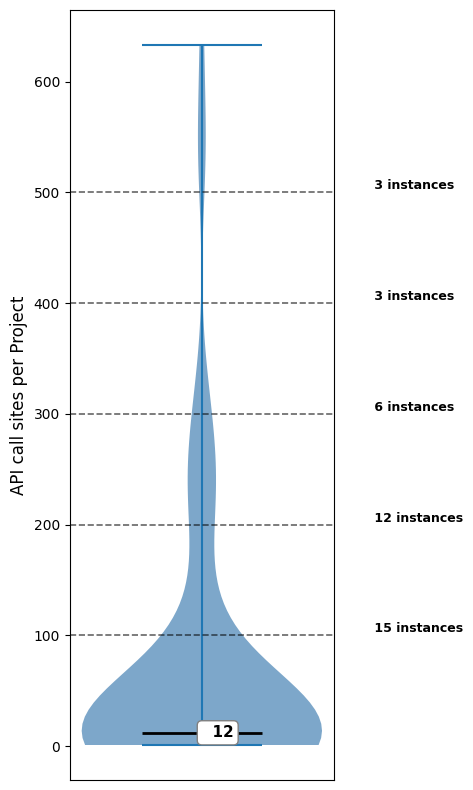

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIG ---
EXP7_PATH = "/Volumes/Rachna-HD/FilteredDataset/Exp7Prompts"  # <-- update this
TOTAL_EXPECTED = 5790

# --- COUNT USAGES PER PROJECT ---
rows = []
for project in sorted(os.listdir(EXP7_PATH)):
    project_dir = os.path.join(EXP7_PATH, project)
    if os.path.isdir(project_dir):
        usages = sum(1 for f in os.listdir(project_dir) if f.endswith(".txt"))
        rows.append({"project": project, "usages": usages})

df = pd.DataFrame(rows).sort_values("usages", ascending=False)

# --- VALIDATE ---
actual_total = df["usages"].sum()
print(f"Total usages found : {actual_total}")
print(f"Expected total     : {TOTAL_EXPECTED}")
print("✓ Match" if actual_total == TOTAL_EXPECTED else f"✗ Mismatch by {actual_total - TOTAL_EXPECTED:+d}")

# --- VIOLIN PLOT WITH THRESHOLD ANNOTATIONS ---
thresholds = [100, 200, 300, 400, 500]

fig, ax = plt.subplots(figsize=(5, 8))

parts = ax.violinplot(df["usages"], positions=[0], showmedians=True, showextrema=True)
for pc in parts["bodies"]:
    pc.set_facecolor("steelblue")
    pc.set_alpha(0.7)
parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(2)

# Median label
median_val = int(df["usages"].median())
ax.text(0, median_val, f"  {median_val}",
        ha="left", va="center", fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray"))

# Threshold horizontal lines + annotations — all black
for thresh in thresholds:
    count_above = (df["usages"] > thresh).sum()
    if count_above == 0:
        continue
    ax.axhline(thresh, color="black", linestyle="--", linewidth=1.2, alpha=0.6)
    ax.text(0.35, thresh, f" {count_above} instances",
            color="black", fontsize=9, fontweight="bold", va="bottom")

ax.set_xticks([])
ax.set_ylabel("API call sites per Project", fontsize=12)
# ax.set_title(f"Usages per BBC Project\n(N={len(df)}, Total={actual_total})", fontsize=12)
plt.tight_layout()
plt.savefig("violin_usages_annotated.png", dpi=150)
plt.show()


Total usages found : 5790
Expected total     : 5790
 Match


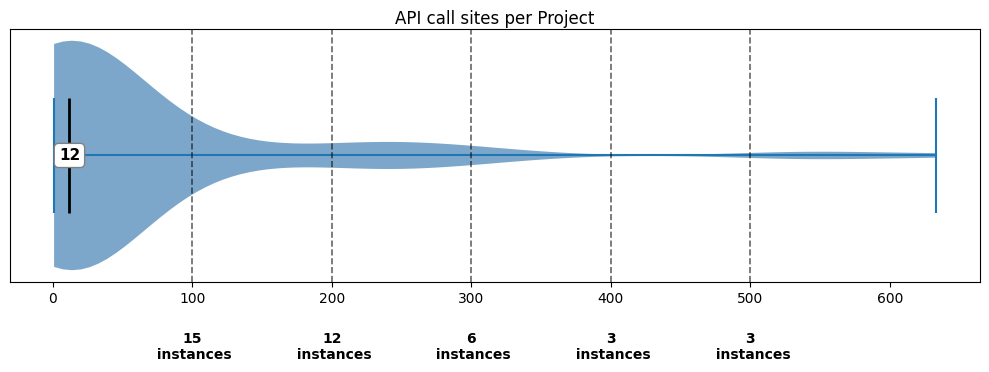

In [25]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIG ---
EXP7_PATH = "/Volumes/Rachna-HD/FilteredDataset/Exp7Prompts"
TOTAL_EXPECTED = 5790

# --- COUNT USAGES PER PROJECT ---
rows = []
for project in sorted(os.listdir(EXP7_PATH)):
    project_dir = os.path.join(EXP7_PATH, project)
    if os.path.isdir(project_dir):
        usages = sum(1 for f in os.listdir(project_dir) if f.endswith(".txt"))
        rows.append({"project": project, "usages": usages})

df = pd.DataFrame(rows).sort_values("usages", ascending=False)

# --- VALIDATE ---
actual_total = df["usages"].sum()
print(f"Total usages found : {actual_total}")
print(f"Expected total     : {TOTAL_EXPECTED}")
print(" Match" if actual_total == TOTAL_EXPECTED else f" Mismatch by {actual_total - TOTAL_EXPECTED:+d}")

# --- HORIZONTAL VIOLIN PLOT WITH THRESHOLD ANNOTATIONS ---
thresholds = [100, 200, 300, 400, 500]
median_val = int(df["usages"].median())

fig, ax = plt.subplots(figsize=(10, 4))

parts = ax.violinplot(df["usages"], positions=[0], showmedians=True,
                      showextrema=True, vert=False)
for pc in parts["bodies"]:
    pc.set_facecolor("steelblue")
    pc.set_alpha(0.7)
parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(2)

# Median label
ax.text(median_val, 0, f"{median_val}",
        ha="center", va="center", fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray"))

# Threshold vertical lines + annotations
for thresh in thresholds:
    count_above = (df["usages"] > thresh).sum()
    if count_above == 0:
        continue
    ax.axvline(thresh, color="black", linestyle="--", linewidth=1.2, alpha=0.6)
    ax.text(thresh, -0.45, f"{count_above}\n instances",
            color="black", fontsize=10, fontweight="bold", ha="center", va="bottom")

ax.set_yticks([])
ax.xaxis.set_label_position('top')
ax.xaxis.tick_bottom()
ax.set_xlabel("API call sites per Project", fontsize=12)
plt.tight_layout()
plt.savefig("violin_usages_horizontal.png", dpi=150)
plt.show()


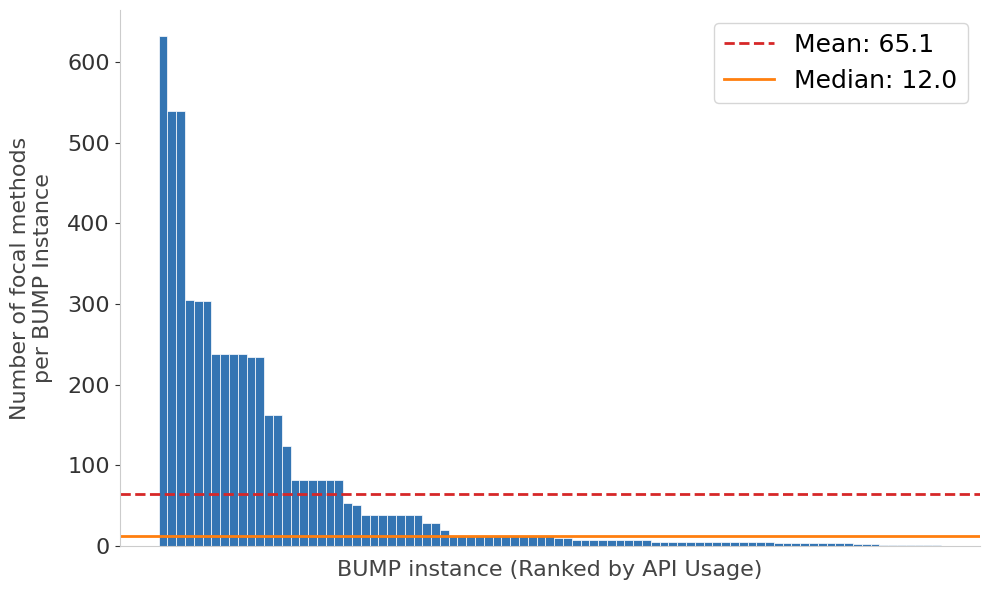

In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIG ---
EXP7_PATH = "/Volumes/Rachna-HD/FilteredDataset/Exp7Prompts"
TOTAL_EXPECTED = 5790

# --- COUNT USAGES PER PROJECT ---
rows = []
if not os.path.exists(EXP7_PATH):
    raise FileNotFoundError(f"Cannot find path: {EXP7_PATH}. Please check your drive.")

for project in sorted(os.listdir(EXP7_PATH)):
    project_dir = os.path.join(EXP7_PATH, project)
    if os.path.isdir(project_dir):
        usages = sum(1 for f in os.listdir(project_dir) if f.endswith(".txt"))
        rows.append({"project": project, "usages": usages})

# Sort descending to create the "waterfall/long-tail" effect and reset index for ranking
df = pd.DataFrame(rows).sort_values("usages", ascending=False).reset_index(drop=True)

# --- RANK-ORDERED BAR CHART ---
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

# Plot every single project as a bar
ax.bar(df.index, df['usages'], color="#3475b3", width=1.0, edgecolor="white", linewidth=0.5)

# Calculate Median and Mean
median_val = df["usages"].median()
mean_val = df["usages"].mean()

# Add standard reference lines for Mean and Median across the whole dataset
ax.axhline(mean_val, color='#d62728', linestyle='--', linewidth=2, 
           label=f'Mean: {mean_val:.1f}')
ax.axhline(median_val, color='#ff7f0e', linestyle='-', linewidth=2, 
           label=f'Median: {median_val:.1f}')

# --- PROFESSIONAL STYLING ---
# Clean up axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Labels
ax.set_ylabel("Number of focal methods\nper BUMP Instance", 
              fontsize=16, color='#444444', labelpad=10)
ax.set_xlabel("BUMP instance (Ranked by API Usage)", 
              fontsize=16, color='#444444', labelpad=10)

# Soften ticks and grids
ax.tick_params(axis='both', which='major', labelsize=16, colors='#333333')
# ax.grid(axis='y', linestyle=':', alpha=0.6, color='gray')
ax.set_axisbelow(True)

# Hide x-axis numbers (since they just represent arbitrary project rank)
ax.set_xticks([])

# Add legend for the lines
ax.legend(fontsize=18, loc='upper right', frameon=True, edgecolor='#cccccc')

# Save and Display
plt.tight_layout()
plt.savefig("rank_ordered_bar_chart_no_stats.pdf", dpi=300, bbox_inches='tight')
plt.show()